# ENGR 1451/2451 — Weekly Assignment 2
**10 points**

This assignment applies the descriptive-statistics and visual-exploration methods introduced in the W02A lab notebooks: center and spread, quartiles and outliers, histograms and boxplots, grouped summaries, and the importance of pairing numerical summaries with visualizations.


 **Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.


## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.


## Setup

Put `iris.csv` in a folder named `data` next to this notebook so that the path below works.


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

iris = pd.read_csv(Path("./data/iris.csv"))
iris.head()


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## LE2-1. Shifting and scaling data (2 pts)

Consider the following measurements:

\[
x = [4,\ 6,\ 8,\ 10,\ 12].
\]

Create two transformed versions:

- **shifted:** \(x + 7\)
- **scaled:** \(3x\)

### A. Predict first (1 pt)

Without calculating, predict what happens to the **mean**, **median**, **sample standard deviation**, and **IQR** after each transformation.

Complete the table in words such as *increases by 7*, *unchanged*, or *multiplied by 3*.

| Statistic | After adding 7 | After multiplying by 3 |
|---|---|---|
| Mean | increases by 7 | multiplied by 3 |
| Median | increases by 7 | multiplied by 3 |
| Sample standard deviation | unchanged | multiplied by 3 |
| IQR | unchanged | multiplied by 3 |


**Answer:**

### B. Verify with Python (1.5 pts)

Create a small summary table for the original, shifted, and scaled data containing:

- mean;
- median;
- sample standard deviation; and
- IQR.

Then state whether the results agree with your predictions.



In [12]:
x = pd.Series([4, 6, 8, 10, 12], name="original")

#define a function that will return an array of the summary statistics
def summary_table(values):
    mean = values.mean()
    median = values.median()
    std = values.std(ddof=1)
    iqr = values.quantile(0.75) - values.quantile(0.25)
    array = np.array([mean, median, std, iqr])
    return(array)

#make the new arrays
shifted = x + 7
scaled = 3 * x

#pass all arrays through the function
shifted_array = summary_table(shifted)
scaled_array = summary_table(scaled)
original_array = summary_table(x)

#combine all of the summary stats into one array so we can treat it as a dataframe below
big_array = [original_array, shifted_array, scaled_array]

display(pd.DataFrame(
    big_array,
    columns = ["mean", "median", "std", "iqr"],
    index = ["original", "shifted", "scaled"]
))


,mean,median,std,iqr
original,8.0,8.0,3.162278,4.0
shifted,15.0,15.0,3.162278,4.0
scaled,24.0,24.0,9.486833,12.0


**Answer:**
yes it agreed with my prediction

## LE2-2. Quartiles, IQR, and outliers (2 pts)

Use the Iris variable `sepal.width`.

1. Calculate \(Q_1\), the median, and \(Q_3\).
2. Calculate the IQR.
3. Calculate the lower and upper Tukey fences:
   \[
   Q_1 - 1.5\,\mathrm{IQR}
   \qquad\text{and}\qquad
   Q_3 + 1.5\,\mathrm{IQR}.
   \]
4. Use Python to identify every Iris observation whose `sepal.width` falls outside these fences.
5. Report how many observations are flagged and state whether they are low outliers, high outliers, or both.


In [78]:
sepal_width = iris["sepal.width"]

# Useful pattern:
# q1 = sepal_width.quantile(0.25)

# Your code here
q1 = sepal_width.quantile(0.25)
median = sepal_width.median()
q3 = sepal_width.quantile(0.75)

iqr = q3 - q1

#define Tukey fences
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

#create an array with the index and values of outliers
lower_outliers = sepal_width.loc[(sepal_width < lower)]
upper_outliers = sepal_width.loc[(sepal_width > upper)]

print("lower outliers are:")
print(lower_outliers)
print("upper outliers are:")
print(upper_outliers)
print("There are ", lower_outliers.count() + upper_outliers.count(), " outliers")

#find extreme outliers
super_lower = q1 - 3*iqr
super_upper = q3 + 3*iqr
super_outliers = sepal_width.loc[(sepal_width < super_lower) | (sepal_width > super_upper)]
print("There are ",super_outliers.count()," super outliers")

lower outliers are:
60    2.0
Name: sepal.width, dtype: float64
upper outliers are:
15    4.4
32    4.1
33    4.2
Name: sepal.width, dtype: float64
There are  4  outliers
There are  0  super outliers


**Answer:**
There were four outliers total: one low outlier (below q1), three high outliers (above q3), and no extreme outliers

## LE2-3. Visualizing a distribution and comparing groups (4 pts)

Use `sepal.length` for all parts below.

### A. Histograms and bin choice (1.5 pts)

Create two histograms of the **same** `sepal.length` data:
- one using **6 bins**;
- one using **18 bins**.

Give each plot meaningful axis labels and a title. Then explain briefly:
1. what features of the distribution appear in both histograms; and
2. what changes when the number of bins changes.


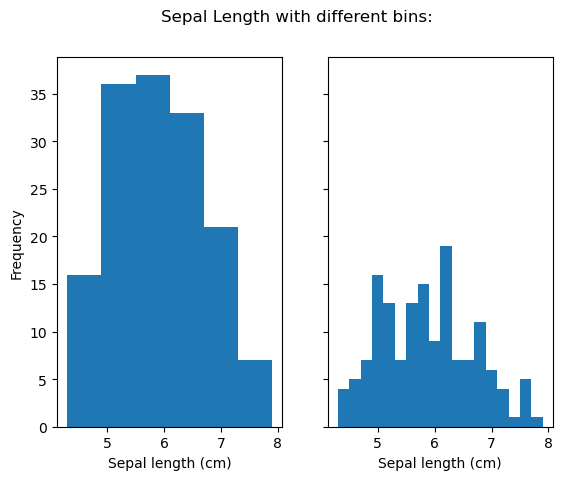

In [80]:
# Your histogram code here
sepal_length = iris["sepal.length"]
fig, axes = plt.subplots(
    1,
    2,
    sharey = True)
sepal_length.plot.hist(bins = 6, ax=axes[0])
axes[0].set_xlabel("Sepal length (cm)")
axes[0].set_ylabel("Frequency")
sepal_length.plot.hist(bins = 18, ax=axes[1])
axes[1].set_xlabel("Sepal length (cm)")
plt.suptitle("Sepal Length with different bins:")
plt.show()

**Answer:**
1. With 6 bins, it looks like the data is close to symmetric and there are no outliers. With 18 bins, there are some high sepal length data points that can be identified in the second highest bin.
2. When the number of bins increases, the bars will be lower for frequency because the data is split up more. With enough bins you can get a good idea of the distribution of the data but too many bins would 'flatten' out the data too much and you couldn't evaluate much


### B. Grouped numerical summary (1 pt)

Calculate the `count`, `median`, sample `std`, `min`, and `max` of `sepal.length` for each Iris species using `groupby()` and `agg()`.

Which species has the largest median `sepal.length`? Which has the largest sample standard deviation?


In [51]:
# Useful pattern:
# iris.groupby("variety")["sepal.length"].agg([...])

# Your code here

sepal_length_each_species = iris.groupby("variety")["sepal.length"].agg(["count", "median", "std", "min", "max"])
print(sepal_length_each_species)

            count  median       std  min  max
variety                                      
Setosa         50     5.0  0.352490  4.3  5.8
Versicolor     50     5.9  0.516171  4.9  7.0
Virginica      50     6.5  0.635880  4.9  7.9


**Answer:**
Virginica has the largest median sepal length.
Virginica has the highest standard deviation in sepal length.

### C. Boxplot by species (1.5 pts)

Create a boxplot of `sepal.length` grouped by `variety`.

Give the plot a clear title and axis labels. Then state **two conclusions** supported by the boxplot: one about differences in center and one about differences in spread or overlap among the species.


Text(0.5, 0, 'Species')

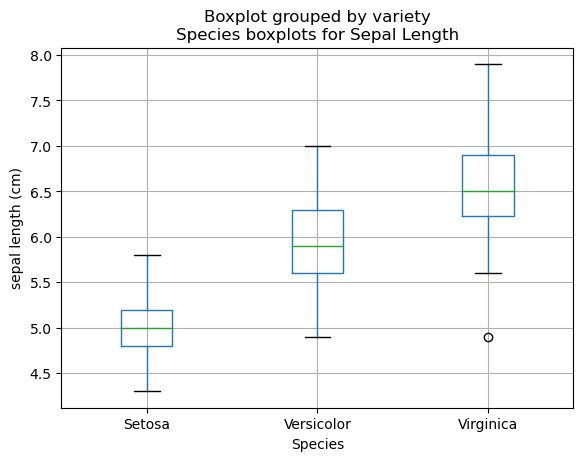

In [57]:
# Useful pattern:
# iris.boxplot(column="...", by="...")

# Your code here
iris.boxplot(column = "sepal.length", by = "variety")
plt.title("Species boxplots for Sepal Length")
plt.ylabel("sepal length (cm)")
plt.xlabel("Species")

**Answer:**
Each species has a different median but all three overlap in overall data. Virginica looks like it has the highest range especially with its lower outlier.

## LE2-4. Similar summaries can hide different distributions (2 pts)

The two datasets below have the same mean, median, and sample standard deviation, but their distributions are not the same.

### A. Compare numerical summaries (0.75 pt)

For datasets A and B, calculate the:
- mean;
- median; and
- sample standard deviation.

Confirm that these three numerical summaries are the same (or equal to rounding).


In [67]:
comparison = pd.DataFrame(
    {
        "A": [1, 2, 3, 4, 5, 6, 7, 8, 9],
        "B": [0, 3, 4, 5, 5, 5, 6, 7, 10],
    }
)



# Useful pattern:
# comparison.agg(["mean", "median", "std"])

# Your code here
comparison_table = comparison.agg(["mean", "median", "std"])
print(comparison_table)
#print(comparison_table.iloc[0,0])
if comparison_table.iloc[0,0] == comparison_table.iloc[0,1] and comparison_table.iloc[1,0] == comparison_table.iloc[1,1] and comparison_table.iloc[2,0] == comparison_table.iloc[2,1]:
    print("they are the same")
else:
    print("they are different")

               A         B
mean    5.000000  5.000000
median  5.000000  5.000000
std     2.738613  2.738613
they are the same


### B. Visualize the distributions (0.75 pt)

Choose **one** of the following ways to compare datasets A and B:
- histograms using the same bins and x-axis scale; or
- boxplots shown on the same figure.

Give the visualization a clear title and meaningful axis labels.


<function matplotlib.pyplot.show(close=None, block=None)>

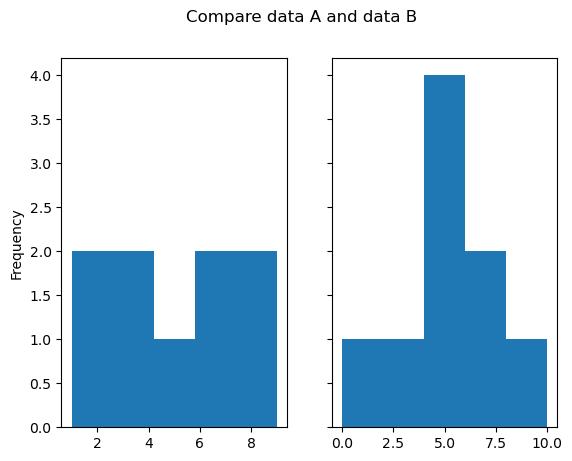

In [77]:
# Your visualization code here
fig, axes = plt.subplots(
    1,
    2,
    sharey = True)
comparison["A"].plot.hist(bins = 5, ax=axes[0])

axes[0].set_ylabel("Frequency")
comparison["B"].plot.hist(bins = 5, ax=axes[1])
plt.suptitle("Compare data A and data B")
plt.show

### C. Interpret (0.5 pt)

What important difference between datasets A and B is visible in your plot but hidden by the mean, median, and sample standard deviation?

In one or two sentences, explain why numerical summaries and visualizations should be used together.

**Answer:**
I chose a number of bins (5) reasonably lower than the nine given data points. Here it looks like data A is symmetric but it is actually evenly spaced. Data B has more data points near its center and looks like it is not symmetric even though it is.
The summary stats hide this. Because they are identical, it may lead you to think that the spread of the data is identical as well.

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.


<!-- Paste your session record blocks in this cell, one after another. -->

*(session records go here)*
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA2",
  "export_n": 1,
  "session_date": "2026-09-15",
  "messages": [
    {"i": 1, "who": "student", "text": "can you help me see what causes an error in this code: # Your histogram code here\nsepal_length = iris[\"sepal.length\"]\naxes = plt.subplots(\n    1,\n    2,\n    sharey = True)\nsepal_length.plot.hist(bins = 6, ax=axes[0])\naxes[0].set_xlabel(\"Sepal length (cm)\")\naxes[0].set_ylabel(\"Frequency\")\nsepal_length.plot.hist(bins = 18, ax=axes[1])\naxes[1].set_xlabel(\"Sepal length (cm)\")\n#axes[1].set_ylabel(\"Frequency\")\nplt.show", "code": true},
    {"i": 2, "who": "tutor", "text": "Good, this is close — let's trace it. What error message are you actually seeing when you run this? If you haven't run it yet, here's the concept to check first: plt.subplots(1, 2, sharey=True) returns a tuple (fig, array_of_two_axes), not just the axes array, so axes[0] gives you the figure object, not your first subplot — and a Figure doesn't have .set_xlabel(). The fix pattern is fig, axes = plt.subplots(1, 2, sharey=True). Also check plt.show — does it have parentheses to actually call it?"},
    {"i": 3, "who": "student", "text": "can you check my work for q 1 - a: Complete the table in words such as *increases by 7*, *unchanged*, or *multiplied by 3*.\n\n| Statistic | After adding 7 | After multiplying by 3 |\n|---|---|---|\n| Mean | increases by 7 | multiplied by 3 |\n| Median | increases by 7 | multiplied by 3 |\n| Sample standard deviation | unchanged | multiplied by 3 |\n| IQR | unchanged | multiplied by 3 |"},
    {"i": 4, "who": "tutor", "text": "These are your predictions to work out, so I can't confirm or correct the table for you — that's the graded part of this step. Think about it this way for each row: does the transformation change how spread out the values are relative to each other, or does it just move/stretch everything the same way? Try applying that question to each row yourself."},
    {"i": 5, "who": "student", "text": "does this fulfill all of q 1  - b? : x = pd.Series([4, 6, 8, 10, 12], name=\"original\")\n\n#define a function that will return an array of the summary statistics\ndef summary_table(values):\n    mean = values.mean()\n    median = values.median()\n    std = values.std(ddof=1)\n    iqr = values.quantile(0.75) - values.quantile(0.25)\n    array = np.array([mean, median, std, iqr])\n    return(array)\n\n#make the new arrays\nshifted = x + 7\nscaled = 3 * x\n\n#pass all arrays through the function\nshifted_array = summary_table(shifted)\nscaled_array = summary_table(scaled)\noriginal_array = summary_table(x)\n\n#combine all of the summary stats into one array so we can treat it as a dataframe below\nbig_array = [original_array, shifted_array, scaled_array]\n\ndisplay(pd.DataFrame(\n    big_array,\n    columns = [\"mean\", \"median\", \"std\", \"iqr\"],\n    index = [\"original\", \"shifted\", \"scaled\"]\n))", "code": true},
    {"i": 6, "who": "tutor", "text": "The table part is solid — mean, median, sample std (ddof=1), and IQR (Q3-Q1) for all three. Check: did you import numpy as np earlier, since your function calls np.array? Also, the prompt asks you to state whether the results agree with your predictions — that written sentence is still missing. Want to add that comparison?"},
    {"i": 7, "who": "student", "text": "does this fulfill question 2?: sepal_width = iris[\"sepal.width\"]\n\n# Useful pattern:\n# q1 = sepal_width.quantile(0.25)\n\n# Your code here\nq1 = sepal_width.quantile(0.25)\nmedian = sepal_width.median()\nq3 = sepal_width.quantile(0.75)\n\niqr = q3 - q1\n\n#define Tukey fences\nlower = q1 - 1.5*iqr\nupper = q3 + 1.5*iqr\n\n#create an array with the index and values of outliers\nlower_outliers = sepal_width.loc[(sepal_width < lower)]\nupper_outliers = sepal_width.loc[(sepal_width > upper)]\n\nprint(\"lower outliers are:\")\nprint(lower_outliers)\nprint(\"upper outliers are:\")\nprint(upper_outliers)\nprint(\"There are \", lower_outliers.count() + upper_outliers.count(), \" outliers\")\n\n#find extreme outliers\nsuper_lower = q1 - 3*iqr\nsuper_upper = q3 + 3*iqr\nsuper_outliers = sepal_width.loc[(sepal_width < super_lower) | (sepal_width > super_upper)]\nprint(\"There are \",super_outliers.count(),\" super outliers\")", "code": true},
    {"i": 8, "who": "tutor", "text": "Your logic is right — Q1, median, Q3, IQR, both fences, and the two masks are all built correctly, covering items 1-4. Based on a reference iris dataset I checked, you should get roughly 1 low outlier and 3 high outliers (4 total) — do your counts match? Still missing: a written statement in the Answer cell reporting the count and whether they're low, high, or both."},
    {"i": 9, "who": "student", "text": "does this fulfill q3 - a?: # Your histogram code here\nsepal_length = iris[\"sepal.length\"]\nfig, axes = plt.subplots(\n    1,\n    2,\n    sharey = True)\nsepal_length.plot.hist(bins = 6, ax=axes[0])\naxes[0].set_xlabel(\"Sepal length (cm)\")\naxes[0].set_ylabel(\"Frequency\")\nsepal_length.plot.hist(bins = 18, ax=axes[1])\naxes[1].set_xlabel(\"Sepal length (cm)\")\n#axes[1].set_ylabel(\"Frequency\")\nplt.show", "code": true},
    {"i": 10, "who": "tutor", "text": "Good, the unpacking fix worked. Still missing: titles on both axes (mentioning the bin counts, 6 vs 18), and plt.show still needs parentheses to actually be called. Also still need the written comparison of the two histograms."},
    {"i": 11, "who": "student", "text": "here is the open answer part, can you check it: 1. With 6 bins, it looks like the data is close to symmetric and there are no outliers. With 18 bins, upper outliers can be identified in the second highest bin.\n2. When the number of bins increases, the bars will be lower for frequency because the data is split up more. With enough bins you can get a good idea of the distribution of the data but too many bins would 'flatten' out the data too much and you couldn't evaluate much"},
    {"i": 12, "who": "tutor", "text": "This is your protected written answer, so I won't rewrite it, but flagging: based on reference sepal.length data (min 4.3, max 7.9, fences ~3.15/8.35), there are no formal Tukey outliers — so point 1's outlier claim may not hold up; it might be a tail bump rather than a statistical outlier. Point 2 is solid. Want to revise point 1 after a closer look at your plot?"},
    {"i": 13, "who": "student", "text": "can you check q 4  - c (interpret): I chose a number of bins (5) reasonably lower than the nine given data points. Here it looks like data A is symmetric but it is actually evenly spaced. Data B has more data points near its center and is not symmetric.\nThe summary stats hide this. Because they are identical, it may lead you to think that the spread of the data is identical as well."},
    {"i": 14, "who": "tutor", "text": "This is your protected answer, so I won't rewrite it, but check the symmetry claim on B: reflecting B's sorted values around its median (5) gives the same set of numbers back, so B is actually symmetric, like A. The real shape difference is that A is uniform/flat across its range while B is peaked at the center with sparser tails. Want to revise the sentence with that distinction?"},
    {"i": 15, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 1, "part": "2-3A", "type": "code"},
    {"i": 5, "part": "2-1B", "type": "code"},
    {"i": 7, "part": "2-2", "type": "code"},
    {"i": 9, "part": "2-3A", "type": "code"}
  ],
  "parts": [
    {"part": "2-1A", "exchanges": 1, "max_tier": 1, "passed": false},
    {"part": "2-1B", "exchanges": 1, "max_tier": 2, "passed": false},
    {"part": "2-2", "exchanges": 1, "max_tier": 2, "passed": false},
    {"part": "2-3A", "exchanges": 3, "max_tier": 3, "passed": false},
    {"part": "2-4C", "exchanges": 1, "max_tier": 2, "passed": false}
  ],
  "tutor_assessment": [
    "Longest friction was on LE2-3A: a plt.subplots unpacking bug had to be diagnosed first, then the written histogram comparison needed revision because the outlier claim didn't hold up against reference fence values.",
    "No release valve or 'I got it' shortcuts were used this session; all feedback stayed within normal checking and redirection, so no sign of tutoring failure."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.
